<a href="https://colab.research.google.com/github/rathoretina07/Assignments-SIP-/blob/main/(asign_1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

QUESTION 1

In [ ]:
!pip install pandas openpyxl

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [ ]:
file_path = 'asssn_4.csv'
df=pd.read_csv(file_path)
print(df.head())

     x          y
0  0.1  20.635590
1  0.2  11.659328
2  0.3  18.775788
3  0.4 -57.616291
4  0.5   0.999924


Statistical Method:
Best fit line equation: Y = 3.0415 * X + 0.4198


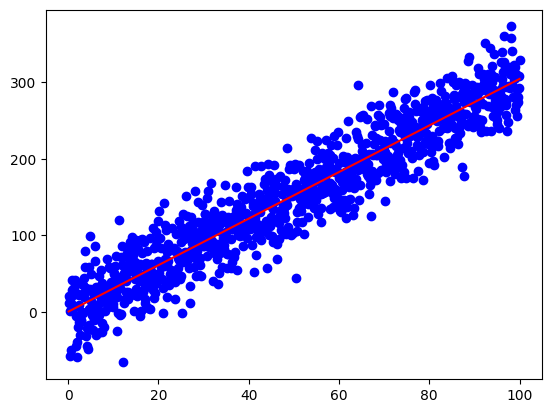

In [ ]:
X=df['x']
Y=df['y']
meanx=np.mean(X)
meany=np.mean(Y)
n=len(X)
num=np.sum((X-meanx)*(Y-meany))
den=np.sum((X-meanx)**2)
m=num/den
b1=meany-m*meanx
print(f"Statistical Method:")
print(f"Best fit line equation: Y = {m:.4f} * X + {b1:.4f}")

plt.scatter(X, Y, color='blue', label='Data Points')
plt.plot(X,m*X+b1,color='red')

PART B

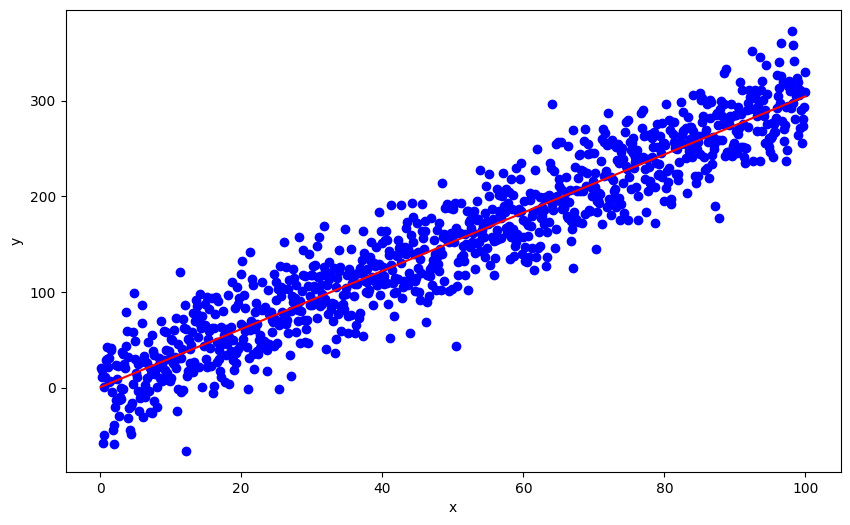

Best fit line: y = 3.0415x + 0.4198


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# shakalaka loading data
df = pd.read_csv("asssn_4.csv")
x = df['x'].values
y = df['y'].values

x_mean, xstd = np.mean(x), np.std(x)  # normalizing data is necessary here becoz the dataset has large value range in x and y
y_mean, ystd = np.mean(y), np.std(y)
x_norm = (x - x_mean) / xstd
y_norm = (y - y_mean) / ystd

# parameters
m = 0
b = 0
learning_rate = 0.01
epochs = 1000
n = len(x_norm)

#the primary shit of Gradient Descent
for _ in range(epochs):
    y_pred = m * x_norm + b
    error = y_norm - y_pred
    dm = (-2/n) * np.dot(x_norm, error)
    db = (-2/n) * np.sum(error)
    m -= learning_rate * dm
    b -= learning_rate * db

# Convert parameters back to original scale
m_original = m * (ystd / xstd)
b_original = y_mean - m_original * x_mean

# Plotting
x_line = np.linspace(min(x), max(x), 100)
y_line = m_original * x_line + b_original

plt.figure(figsize=(10, 6))
plt.scatter(x, y, color='blue', label='Data Points')
plt.plot(x_line, y_line, color='red', label=f'Best Fit Line: y = {m_original:.2f}x + {b_original:.2f}')
plt.xlabel('x')
plt.ylabel('y')
plt.show()

print(f"Best fit line: y = {m_original:.4f}x + {b_original:.4f}")


PART C

In [ ]:
from sklearn.linear_model import LinearRegression


Scikit-learn Method:
Best fit line equation: Y = 3.0415 * X + 0.4198


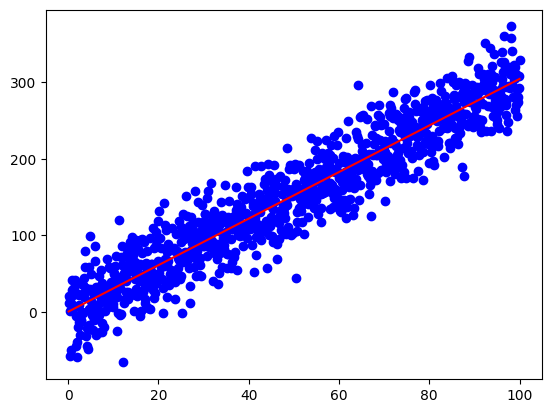

In [ ]:
X_reshaped = X.values.reshape(-1, 1)
model = LinearRegression()
model.fit(X_reshaped, Y)
bs= model.intercept_
ms = model.coef_[0]
y_pred = model.predict(X_reshaped)

print(f"\nScikit-learn Method:")
print(f"Best fit line equation: Y = {ms:.4f} * X + {bs:.4f}")

plt.scatter(X, Y, color='blue', label='Data Points')
plt.plot(X_reshaped,y_pred, color='Red', label='Scikit-learn Line')

QUESTION 2

In [ ]:
df = pd.read_excel("asssn_4.xlsx", sheet_name="Q2")


Linear Regression Equation: y = 29.9328x + -48.4601
Polynomial Regression Equation (degree 2):
y = 0.1744 + 0.8104x^1 + 2.9093x^2


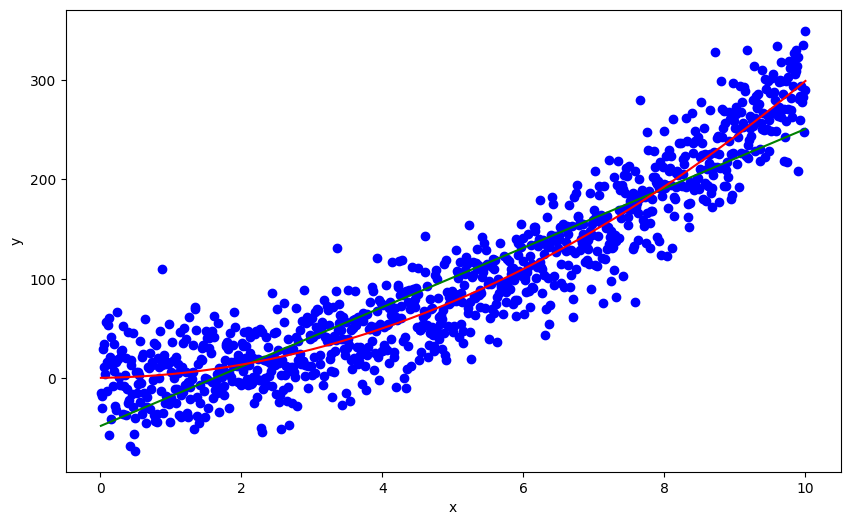

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures

X = df['x'].values.reshape(-1, 1)
Y = df['y'].values.reshape(-1, 1)
linear_model = LinearRegression()
linear_model.fit(X, Y)
Y_pred = linear_model.predict(X)

# Polynomial Regression (degree 2)
poly = PolynomialFeatures(degree=2)   #USED BOTH DEGREE 1 AND DEGREE 2 CURVE TO CHECK WHICH FITS BETTER
X_poly = poly.fit_transform(X)
poly_model = LinearRegression()
poly_model.fit(X_poly, Y)
Y_pred_poly = poly_model.predict(X_poly)

# Print equations
m = linear_model.coef_[0][0]
b = linear_model.intercept_[0]
print(f"Linear Regression Equation: y = {m:.4f}x + {b:.4f}")

coefs = poly_model.coef_.flatten()
intercept = poly_model.intercept_[0]
poly_eq = f"y = {intercept:.4f}"
for i in range(1, len(coefs)):
    poly_eq += f" + {coefs[i]:.4f}x^{i}"
print("Polynomial Regression Equation (degree 2):")
print(poly_eq)

# Plotting
plt.figure(figsize=(10, 6))
plt.scatter(X, Y, color='blue', label='Data Points')
plt.plot(X, Y_pred, color='green', label='Linear Fit (Degree 1)')
plt.plot(X, Y_pred_poly, color='red', label='Polynomial Fit (Degree 2)')
plt.xlabel("x")
plt.ylabel("y")
plt.show()


QUESTION 3

In [ ]:
from sklearn.preprocessing import StandardScaler
df = pd.read_excel("asssn_4.xlsx", sheet_name="Q3")


In [ ]:

X = df[['x1', 'x2', 'x3', 'x4']].values
y = df['y'].values.reshape(-1, 1)

# Statistical Method
X_b = np.hstack([np.ones((X.shape[0], 1)), X])  # Add bias term
theta_stat = np.linalg.inv(X_b.T @ X_b) @ X_b.T @ y
print("\nQ3a: Statistical Method")
print("Best fit line:")
print(f"y = {theta_stat[0][0]:.4f} + {theta_stat[1][0]:.4f}*x1 + {theta_stat[2][0]:.4f}*x2 + "
      f"{theta_stat[3][0]:.4f}*x3 + {theta_stat[4][0]:.4f}*x4")

# Gradient Descent Method (with scaling)
def gradient_descent(X, y, lr=0.01, iterations=10000):
    m, n = X.shape
    X_b = np.hstack([np.ones((m, 1)), X])
    theta = np.zeros((n + 1, 1))
    for _ in range(iterations):
        y_pred = X_b @ theta
        error = y_pred - y
        gradients = (2/m) * (X_b.T @ error)
        theta -= lr * gradients
    return theta

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
theta_gd = gradient_descent(X_scaled, y, lr=0.01, iterations=10000)

print("\nQ3b: Gradient Descent Method (on standardized data)")
print(f"y = {theta_gd[0][0]:.4f} + {theta_gd[1][0]:.4f}*x1 + {theta_gd[2][0]:.4f}*x2 + "
      f"{theta_gd[3][0]:.4f}*x3 + {theta_gd[4][0]:.4f}*x4")

### Q3c: Scikit-learn Method
model = LinearRegression()
model.fit(X, y)

intercept = model.intercept_[0]
coefs = model.coef_.flatten()

print("\nQ3c: Scikit-learn Linear Regression")
print(f"y = {intercept:.4f} + {coefs[0]:.4f}*x1 + {coefs[1]:.4f}*x2 + "
      f"{coefs[2]:.4f}*x3 + {coefs[3]:.4f}*x4")



Q3a: Statistical Method
Best fit line:
y = 200.2407 + 14.1830*x1 + -59.5581*x2 + 0.2488*x3 + 6.9238*x4

Q3b: Gradient Descent Method (on standardized data)
y = 571.6322 + 72.6791*x1 + 72.6791*x2 + 79.9381*x3 + 103.2577*x4

Q3c: Scikit-learn Linear Regression
y = 2.1625 + 4.1610*x1 + 0.4161*x2 + 0.2488*x3 + 6.9238*x4


the huge difference is arriving mostly because of normalising the data

questionn 4

Slope: [ 1.53075777e+02  7.25667708e+02  2.89818271e+02 -2.23963060e+02
  7.07879623e+02 -4.61834334e+02  1.08473330e+01  5.55320620e+01
 -3.48460583e+03 -1.31465716e+03 -1.91021027e+03 -4.28764186e+01
  3.28552393e+00  3.09297566e+02 -1.24218275e+02  1.87530633e+04
  1.13007724e+04  1.41526967e+04  1.73938174e+04  3.75243177e+03
  7.76488081e+03  5.62714233e+03  3.36020061e+03  6.31605105e+03
  1.70789969e+04  2.98126212e+04  2.90827788e+04  3.00116586e+04
  3.95191609e+04  2.85066993e+04  1.70597637e+03  1.14159688e+03
  2.40910416e+03 -1.92707155e+03 -6.53580461e+02  1.03405380e+04
  8.09618346e+02 -2.27651830e+03  5.48587900e+03  7.62185015e+03
  6.47095007e+03  7.76888074e+03  4.79713390e+03  4.03320968e+03
  4.58156275e+03  4.01436484e+03  6.35273930e+03  9.93247075e+03
  4.94605138e+03  5.65292805e+03  1.01381451e+04  6.59904998e+03
  7.81902367e+03  8.79251360e+03  5.29616497e+03  9.48903179e+03
  1.00225544e+04  7.48292444e+03  8.78869343e+03  5.43233112e+03
  4.33606276e+03  

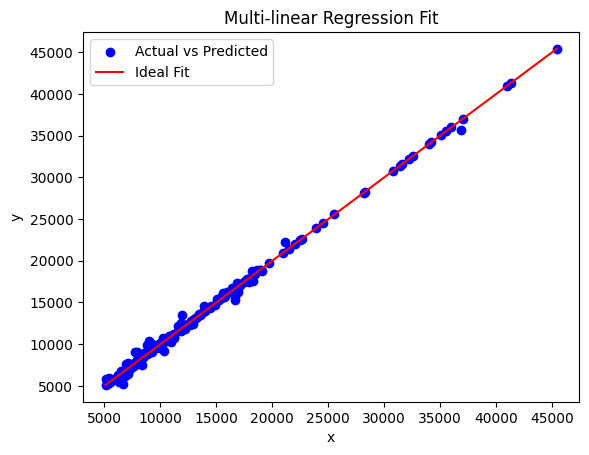

In [ ]:
#best fit line using the sklearn
import pandas as pd
from sklearn.linear_model import LinearRegression
import numpy as np
import matplotlib.pyplot as plt
df= pd.read_csv('CarPrice_Assignment.csv')
#print(df)

df= df.dropna()

x= pd.get_dummies(df.drop(columns='price'),drop_first=True)
x=np.array(x)
#print(x)
y= df['price']
#print(y)


model = LinearRegression()
model.fit(x,y)
slope = model.coef_
intercept = model.intercept_
print("Slope:", slope)
print("Intercept:", intercept)
y_pred = model.predict(x)
plt.scatter(y, y_pred, color='blue', label='Actual vs Predicted')  # Plot original data
plt.plot([min(y), max(y)], [min(y), max(y)], color='red', label='Ideal Fit')  # Plot regression line
plt.xlabel('x')
plt.ylabel('y')
plt.title('Multi-linear Regression Fit')
plt.legend()
plt.show()



Best Fit Line Equation:
y = -12227.3084 + 153.0758*car_ID + 725.6677*symboling + 289.8183*wheelbase + -223.9631*carlength + 707.8796*carwidth + -461.8343*carheight + 10.8473*curbweight + 55.5321*enginesize + -3484.6058*boreratio + -1314.6572*stroke + -1910.2103*compressionratio + -42.8764*horsepower + 3.2855*peakrpm + 309.2976*citympg + -124.2183*highwaympg + 18753.0633*CarName_alfa-romero Quadrifoglio + 11300.7724*CarName_alfa-romero giulia + 14152.6967*CarName_alfa-romero stelvio + 17393.8174*CarName_audi 100 ls + 3752.4318*CarName_audi 100ls + 7764.8808*CarName_audi 4000 + 5627.1423*CarName_audi 5000 + 3360.2006*CarName_audi 5000s (diesel) + 6316.0511*CarName_audi fox + 17078.9969*CarName_bmw 320i + 29812.6212*CarName_bmw x1 + 29082.7788*CarName_bmw x3 + 30011.6586*CarName_bmw x4 + 39519.1609*CarName_bmw x5 + 28506.6993*CarName_bmw z4 + 1705.9764*CarName_buick century + 1141.5969*CarName_buick century luxus (sw) + 2409.1042*CarName_buick century special + -1927.0715*CarName_buick e

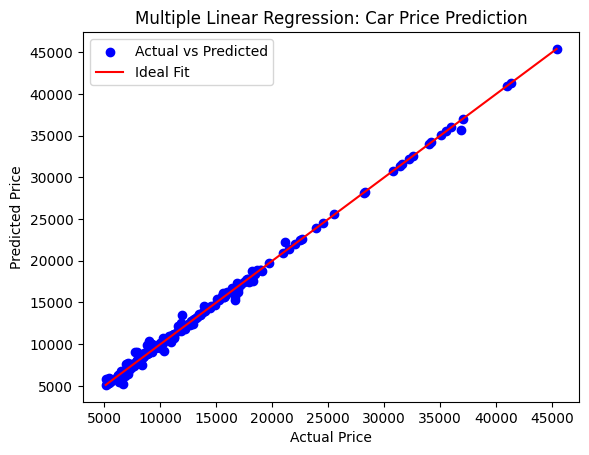

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

# Load and prepare data
df = pd.read_csv('CarPrice_Assignment.csv')
df = df.dropna()

# One-hot encode categorical variables
X = pd.get_dummies(df.drop(columns='price'), drop_first=True)
y = df['price']

# Fit the model
model = LinearRegression()
model.fit(X, y)

# Get slope and intercept
slope = model.coef_
intercept = model.intercept_

# Best fit line equation (print partial)
print("\nBest Fit Line Equation:")
print(f"y = {intercept:.4f} + ", end="")
for feature, coef in zip(X.columns, slope):
    print(f"{coef:.4f}*{feature} + ", end="")
print("\b\b ")

# Predictions
y_pred = model.predict(X)

# Plot: Actual vs Predicted
plt.scatter(y, y_pred, color='blue', label='Actual vs Predicted')
plt.plot([min(y), max(y)], [min(y), max(y)], color='red', label='Ideal Fit')
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.title('Multiple Linear Regression: Car Price Prediction')
plt.legend()
plt.show()


question 5


Best Fit Line:
y = -11938.54 + 256.86*age + 339.19*bmi + 475.50*children + -131.31*sex_male + 23848.53*smoker_yes + -352.96*region_northwest + -1035.02*region_southeast + -960.05*region_southwest +  


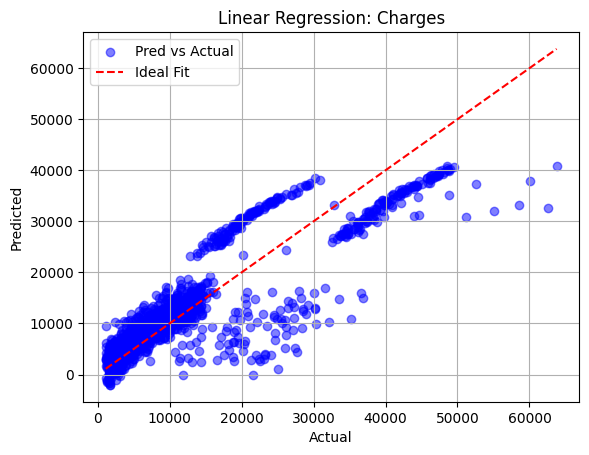

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

# Load and clean data
df = pd.read_csv('insurance.csv')
df = df.dropna()

# Features and target
X = pd.get_dummies(df.drop(columns='charges'), drop_first=True)
y = df['charges']

# Train model
lr = LinearRegression()
lr.fit(X, y)

# Coefficients
b = lr.intercept_
w = lr.coef_

# Print best fit line
print("\nBest Fit Line:")
print(f"y = {b:.2f} + ", end="")
for n, c in zip(X.columns, w):
    print(f"{c:.2f}*{n} + ", end="")
print("\b\b ")

# Predictions
y_pred = lr.predict(X)

# Plot
plt.scatter(y, y_pred, color='b', alpha=0.5, label='Pred vs Actual')
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', label='Ideal Fit')
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.title('Linear Regression: Charges')
plt.legend()
plt.grid(True)
plt.show()


model not performing well dont know how to improove it yet